Using customer retail dataset implement various models and compare them.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [28]:
df=pd.read_csv("customer_retail csv file.csv")

In [29]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER       6.0   
1    536365     71053                  WHITE METAL LANTERN       6.0   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER       8.0   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE       6.0   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.       6.0   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [30]:
df=df.dropna()

In [31]:
df=pd.read_csv("customer_retail csv file.csv")
df=df.dropna()
df = df[df['Quantity'] > 0]
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,01-12-2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
148339,549234,22277,COSMETIC BAG VINTAGE ROSE PAISLEY,1.0,07-04-2011 11:12,2.10,16515.0,United Kingdom
148340,549234,22264,FELT FARM ANIMAL WHITE BUNNY,1.0,07-04-2011 11:12,0.85,16515.0,United Kingdom
148341,549234,21172,PARTY METAL SIGN,1.0,07-04-2011 11:12,1.45,16515.0,United Kingdom
148342,549234,21770,OPEN CLOSED METAL SIGN,1.0,07-04-2011 11:12,4.95,16515.0,United Kingdom


In [32]:
df=df[['Quantity','UnitPrice',
'Country']]
df

,Quantity,UnitPrice,Country
0,6.0,2.55,United Kingdom
1,6.0,3.39,United Kingdom
2,8.0,2.75,United Kingdom
3,6.0,3.39,United Kingdom
4,6.0,3.39,United Kingdom
...,...,...,...
148339,1.0,2.10,United Kingdom
148340,1.0,0.85,United Kingdom
148341,1.0,1.45,United Kingdom
148342,1.0,4.95,United Kingdom


In [33]:
encoder=LabelEncoder()
df['Country_encoded']=encoder.fit_transform(df['Country'])


/tmp/ipykernel_7639/3740784400.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Country_encoded']=encoder.fit_transform(df['Country'])


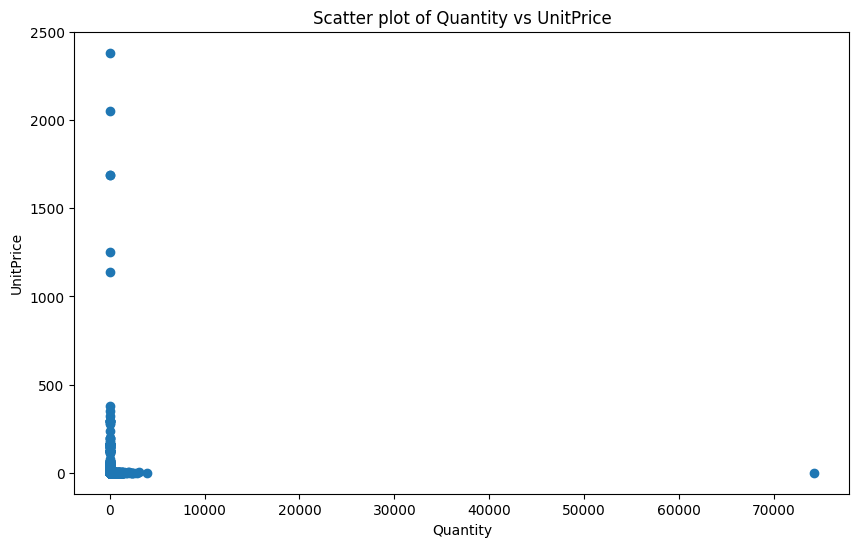

In [34]:
plt.figure(figsize=(10,6))
plt.scatter(df['Quantity'],df['UnitPrice'])
plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title('Scatter plot of Quantity vs UnitPrice')
plt.show()

In [35]:
x=df[['Quantity','UnitPrice']]
y=df['Country_encoded']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [36]:
print("Logistic Regression")
log_model=LogisticRegression()
log_model.fit(x_train,y_train)
y_pred=log_model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)

Logistic Regression
Accuracy: 0.8877833056937534
Confusion Matrix:
[[    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0    60]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     6]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0    71]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     2]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0    49

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:
print("Decision Tree")
dt_model=DecisionTreeClassifier()
dt_model.fit(x_train,y_train)
y_pred=dt_model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)


Decision Tree
Accuracy: 0.8870797527513945
Confusion Matrix:
[[    5     0     0     0     0     0     0     0     0     0     0     1
      0     0     0     0     0     0     0     6     0     0     0     0
      0     0     0     0     0    48]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     6]
 [    0     0     4     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     1     0     0     0     0
      0     0     0     0     0    66]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     2]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     1     0     0     0     0
      0     0     0     0     0    48]
 [  

In [38]:
print("KNN")
knn_model=KNeighborsClassifier()
knn_model.fit(x_train,y_train)
y_pred=knn_model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)

KNN
Accuracy: 0.8538117493341374
Confusion Matrix:
[[    6     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     5     0     0     0     0
      0     0     0     0     0    49]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     6]
 [    0     0     3     0     0     0     0     0     0     0     8     0
      0     0     0     0     0     0     0     1     0     0     0     0
      0     0     0     0     0    59]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     2]
 [    1     0     0     0     0     0     0     0     0     0     1     0
      0     0     0     0     0     0     0     1     0     0     0     0
      0     0     0     0     0    46]
 [    0     0 

In [41]:
models=[
    "Logistic Regression",
    "Decision Tree",
    "KNN"
]
log_accuracy = accuracy_score(y_test, log_model.predict(x_test))

dt_accuracy = accuracy_score(y_test, dt_model.predict(x_test))

knn_accuracy = accuracy_score(y_test, knn_model.predict(x_test))

accuracies = [
    log_accuracy,
    dt_accuracy,
    knn_accuracy
]

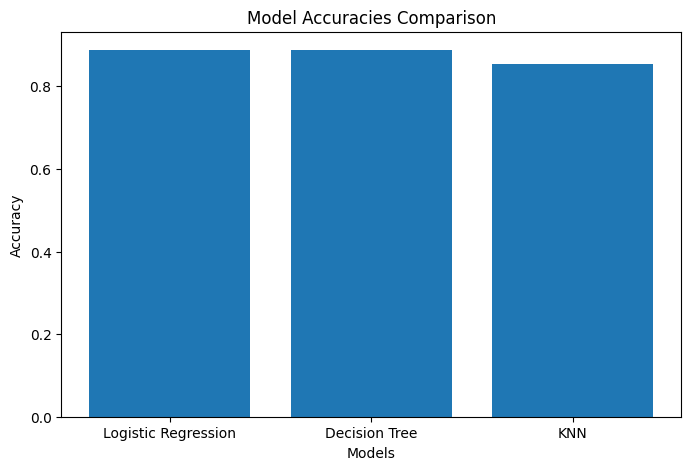

In [42]:
plt.figure(figsize=(8,5))
plt.bar(models,accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracies Comparison")
plt.show()